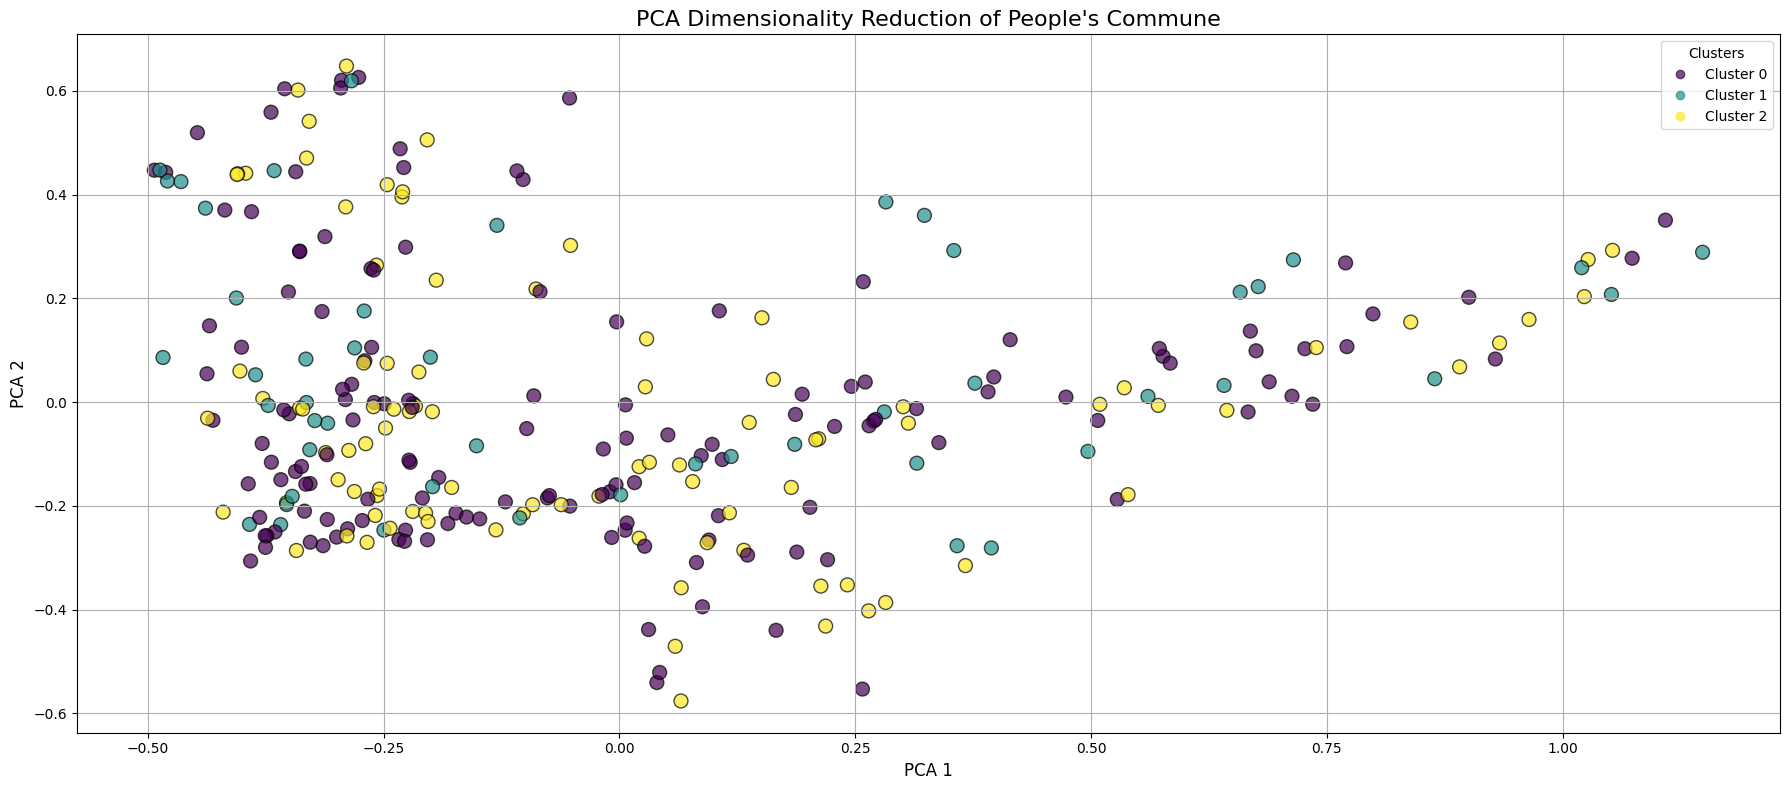

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

# -----------------------
# 1. 读取数据
# -----------------------
df = pd.read_csv(r"E:\00论文\heritage science\0630\Extract_commune_with_cluster.csv")

# -----------------------
# 2. 特征选择（自变量特征）
# -----------------------
features = [
    'Elevation', 'Precipitation', 'Temperature', 'Wind',
    'Distance to canal', 'Distance to railway', 'Distance to ocean',
    'Distance to river', 'Distance to highway', 'Distance to central city'
]
X = df[features]
y = df['cluster']  # 类别标签

# -----------------------
# 3. 归一化处理
# -----------------------
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------
# 4. PCA 降维
# -----------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -----------------------
# 5. 可视化：PCA 降维结果
# -----------------------
plt.figure(figsize=(18, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=100, edgecolors='k', alpha=0.7)

# 添加每个点的公社名称
#for i, txt in enumerate(df['Commune']):
#    plt.annotate(txt, (X_pca[i, 0], X_pca[i, 1]), fontsize=8, alpha=0.7)

# 颜色标注对应的聚类
plt.legend(handles=scatter.legend_elements()[0], labels=['Cluster 0', 'Cluster 1', 'Cluster 2'], title="Clusters")

plt.title("PCA Dimensionality Reduction of People's Commune", fontsize=16)
plt.xlabel("PCA 1", fontsize=12)
plt.ylabel("PCA 2", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()